# 05d — CLEAR Counterfactual FlexPepDock Refinement

## Obiettivo

Questo notebook confronta mediante **Rosetta FlexPepDock**:

- il seed naturale corto `F0010`;
- i migliori controfattuali selezionati dal 05c.

Pannello previsto:

```text
F0010  IGERCQYRDLK      controllo
CF_02  IGERSQYRELK      C5S + D9E
CF_05  IGERCEYRELK      Q6E + D9E
CF_03  IGERCQYRELK      D9E
CF_06  IGERCQYRELR      D9E + K11R
CF_10  IGERCQYRELQ      D9E + K11Q
```

Il notebook:

1. recupera il seed e il manifest 05c;
2. prepara gli input Rosetta;
3. esegue FlexPepDock con `nstruct=20` per candidato;
4. consente la ripresa senza rifare candidati completi;
5. analizza gli score Rosetta;
6. seleziona le migliori pose;
7. calcola:
   - RMSD del peptide;
   - ritenzione dei contatti nativi;
   - precisione dei contatti;
   - hotspot preservati;
   - clash;
8. costruisce un ranking finale seed-vs-CLEAR.

## Nota metodologica

FoldX ha valutato le mutazioni in una posa quasi fissa.  
FlexPepDock permette un rilassamento locale più realistico dell'interfaccia peptide–recettore.


## 1. Dipendenze

```bash
pip install pandas numpy matplotlib biopython
```


In [11]:
from pathlib import Path
from collections import Counter
import json
import math
import os
import re
import shutil
import subprocess
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio.PDB import PDBParser, NeighborSearch, Superimposer, is_aa

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 220)
pd.set_option("display.max_colwidth", 180)

print("Ambiente inizializzato.")

Ambiente inizializzato.


## 2. Configurazione

In [13]:
OUTPUT_DIR = Path("outputs")

VALIDATION_05C_DIR = (
    OUTPUT_DIR / "clear_counterfactual_validation_05c"
)
ROSETTA_05C_DIR = (
    VALIDATION_05C_DIR / "rosetta_candidates"
)

ROSETTA_SELECTION_CSV = (
    VALIDATION_05C_DIR
    / "clear_candidates_selected_for_rosetta.csv"
)
ROSETTA_MANIFEST_05C = (
    ROSETTA_05C_DIR
    / "rosetta_input_manifest.csv"
)

SOURCE_03C_DIR = (
    OUTPUT_DIR / "short_peptide_guided_docking_03c"
)

SEED_PDB_CANDIDATES = [
    SOURCE_03C_DIR
    / "rosetta_flexpepdock"
    / "inputs"
    / "F0010.pdb",
    SOURCE_03C_DIR
    / "inputs"
    / "F0010_native_complex.pdb",
    OUTPUT_DIR
    / "short_peptide_structural_ranking"
    / "native_fragment_complexes"
    / "F0010_BD_D38-48.pdb",
]

RESULT_DIR = (
    OUTPUT_DIR
    / "clear_counterfactual_flexpepdock_05d"
)
INPUT_DIR = RESULT_DIR / "inputs"
RUNS_DIR = RESULT_DIR / "runs"
BEST_POSES_DIR = RESULT_DIR / "best_poses"
TOP5_POSES_DIR = RESULT_DIR / "top5_poses"
REPORTS_DIR = RESULT_DIR / "reports"

for directory in [
    RESULT_DIR,
    INPUT_DIR,
    RUNS_DIR,
    BEST_POSES_DIR,
    TOP5_POSES_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"
SEED_SEQUENCE = "IGERCQYRDLK"

CONTACT_CUTOFF_A = 4.5
CLASH_CUTOFF_A = 2.0

ROSETTA_NSTRUCT = 20
RUN_ROSETTA = True
SKIP_COMPLETE_CANDIDATES = True
BACKUP_INCOMPLETE_RUNS = True

ROSETTA_BINARY_CANDIDATES = [
    "/Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/source/build/src/release/macos/12.7/64/arm/clang/14.0/static/FlexPepDocking.static.macosclangrelease",
    shutil.which("FlexPepDocking.static.macosclangrelease"),
    shutil.which("FlexPepDocking.default.macosclangrelease"),
    shutil.which("FlexPepDocking.linuxgccrelease"),
]

ROSETTA_DATABASE_CANDIDATES = [
    "/Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/database",
]

print("Input 05c:", VALIDATION_05C_DIR.resolve())
print("Output 05d:", RESULT_DIR.resolve())

Input 05c: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c
Output 05d: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d


## 3. Recupero del seed F0010

In [14]:
def resolve_seed_pdb():
    for path in SEED_PDB_CANDIDATES:
        if path.exists():
            return path.resolve()

    matches = sorted(OUTPUT_DIR.rglob("F0010*.pdb"))

    matches = [
        path for path in matches
        if "best_poses" not in str(path)
        and "top5_poses" not in str(path)
        and "clear_counterfactual_flexpepdock_05d" not in str(path)
    ]

    if matches:
        return matches[0].resolve()

    raise FileNotFoundError(
        "PDB seed F0010 non trovato."
    )


SEED_PDB = resolve_seed_pdb()

print("Seed PDB:", SEED_PDB)

Seed PDB: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb


## 4. Recupero dei candidati 05c

In [15]:
if not ROSETTA_SELECTION_CSV.exists():
    raise FileNotFoundError(
        "Selezione Rosetta 05c non trovata."
    )

selection_05c = pd.read_csv(
    ROSETTA_SELECTION_CSV
)

required_columns = {
    "validation_id",
    "sequence",
    "mutation_labels",
    "counterfactual_model_pdb",
    "validation_score",
}

missing = required_columns - set(selection_05c.columns)

if missing:
    raise ValueError(
        "Colonne mancanti: "
        + ", ".join(sorted(missing))
    )

display(
    selection_05c[
        [
            "validation_id",
            "sequence",
            "mutation_labels",
            "foldx_ddG_total_kcal_mol",
            "validation_score",
        ]
    ]
)

,validation_id,sequence,mutation_labels,foldx_ddG_total_kcal_mol,validation_score
0,CF_02,IGERSQYRELK,C5S;D9E,-1.96518,0.750000
1,CF_05,IGERCEYRELK,Q6E;D9E,-1.76706,0.682180
2,CF_03,IGERCQYRELK,D9E,-1.80284,0.672702
3,CF_06,IGERCQYRELR,D9E;K11R,-1.31251,0.587969
4,CF_10,IGERCQYRELQ,D9E;K11Q,-1.23419,0.559090


## 5. Costruzione del pannello seed + controfattuali


In [16]:
panel_rows = [{
    "candidate_id": "F0010",
    "source_id": "F0010",
    "sequence": SEED_SEQUENCE,
    "mutation_labels": "seed_reference",
    "source_pdb": str(SEED_PDB),
    "foldx_ddG_total_kcal_mol": 0.0,
    "validation_score_05c": np.nan,
    "candidate_type": "seed",
}]

for row in selection_05c.itertuples(index=False):
    panel_rows.append({
        "candidate_id": row.validation_id,
        "source_id": row.validation_id,
        "sequence": row.sequence,
        "mutation_labels": row.mutation_labels,
        "source_pdb": row.counterfactual_model_pdb,
        "foldx_ddG_total_kcal_mol": (
            row.foldx_ddG_total_kcal_mol
        ),
        "validation_score_05c": row.validation_score,
        "candidate_type": "clear_counterfactual",
    })

panel = pd.DataFrame(panel_rows)

for row in panel.itertuples(index=False):
    source = Path(row.source_pdb)

    if not source.exists():
        raise FileNotFoundError(
            f"PDB mancante per {row.candidate_id}: {source}"
        )

    target = INPUT_DIR / f"{row.candidate_id}.pdb"
    shutil.copy2(source, target)

panel["input_pdb"] = panel["candidate_id"].apply(
    lambda candidate_id: str(
        INPUT_DIR / f"{candidate_id}.pdb"
    )
)

display(panel)

,candidate_id,source_id,sequence,mutation_labels,source_pdb,foldx_ddG_total_kcal_mol,validation_score_05c,candidate_type,input_pdb
0,F0010,F0010,IGERCQYRDLK,seed_reference,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb,0.00000,NaN,seed,outputs/clear_counterfactual_flexpepdock_05d/inputs/F0010.pdb
1,CF_02,CF_02,IGERSQYRELK,C5S;D9E,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_02_IGERSQYRELK.pdb,-1.96518,0.750000,clear_counterfactual,outputs/clear_counterfactual_flexpepdock_05d/inputs/CF_02.pdb
2,CF_05,CF_05,IGERCEYRELK,Q6E;D9E,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_05_IGERCEYRELK.pdb,-1.76706,0.682180,clear_counterfactual,outputs/clear_counterfactual_flexpepdock_05d/inputs/CF_05.pdb
3,CF_03,CF_03,IGERCQYRELK,D9E,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_03_IGERCQYRELK.pdb,-1.80284,0.672702,clear_counterfactual,outputs/clear_counterfactual_flexpepdock_05d/inputs/CF_03.pdb
4,CF_06,CF_06,IGERCQYRELR,D9E;K11R,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_06_IGERCQYRELR.pdb,-1.31251,0.587969,clear_counterfactual,outputs/clear_counterfactual_flexpepdock_05d/inputs/CF_06.pdb
5,CF_10,CF_10,IGERCQYRELQ,D9E;K11Q,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_10_IGERCQYRELQ.pdb,-1.23419,0.559090,clear_counterfactual,outputs/clear_counterfactual_flexpepdock_05d/inputs/CF_10.pdb


## 6. Verifica strutturale degli input

In [17]:
AA3_TO_1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

parser = PDBParser(QUIET=True)


def standard_residues(chain):
    return [
        residue for residue in chain
        if is_aa(residue, standard=True)
    ]


def sequence_from_chain(chain):
    return "".join(
        AA3_TO_1.get(
            residue.get_resname().upper(),
            "X",
        )
        for residue in standard_residues(chain)
    )


verification_rows = []

for row in panel.itertuples(index=False):
    structure = parser.get_structure(
        row.candidate_id,
        row.input_pdb,
    )
    model = next(structure.get_models())
    chain_ids = [chain.id for chain in model]

    observed_sequence = (
        sequence_from_chain(model[PEPTIDE_CHAIN])
        if PEPTIDE_CHAIN in chain_ids
        else ""
    )

    verification_rows.append({
        "candidate_id": row.candidate_id,
        "expected_sequence": row.sequence,
        "observed_sequence": observed_sequence,
        "chains": ",".join(chain_ids),
        "sequence_ok": observed_sequence == row.sequence,
        "chains_ok": (
            RECEPTOR_CHAIN in chain_ids
            and PEPTIDE_CHAIN in chain_ids
        ),
    })

verification = pd.DataFrame(
    verification_rows
)

display(verification)

if not verification["sequence_ok"].all():
    raise ValueError(
        "Una o più sequenze PDB non coincidono con il pannello."
    )

if not verification["chains_ok"].all():
    raise ValueError(
        "Una o più strutture non contengono le catene B e D."
    )

,candidate_id,expected_sequence,observed_sequence,chains,sequence_ok,chains_ok
0,F0010,IGERCQYRDLK,IGERCQYRDLK,"B,D",True,True
1,CF_02,IGERSQYRELK,IGERSQYRELK,"B,D",True,True
2,CF_05,IGERCEYRELK,IGERCEYRELK,"B,D",True,True
3,CF_03,IGERCQYRELK,IGERCQYRELK,"B,D",True,True
4,CF_06,IGERCQYRELR,IGERCQYRELR,"B,D",True,True
5,CF_10,IGERCQYRELQ,IGERCQYRELQ,"B,D",True,True


## 7. Individuazione di Rosetta

In [18]:
ROSETTA_BINARY = None
ROSETTA_DATABASE = None

for candidate in ROSETTA_BINARY_CANDIDATES:
    if candidate and Path(candidate).exists():
        ROSETTA_BINARY = str(
            Path(candidate).resolve()
        )
        break

for candidate in ROSETTA_DATABASE_CANDIDATES:
    if candidate and Path(candidate).exists():
        ROSETTA_DATABASE = str(
            Path(candidate).resolve()
        )
        break

print("FlexPepDock:", ROSETTA_BINARY)
print("Database:", ROSETTA_DATABASE)

if RUN_ROSETTA and (
    ROSETTA_BINARY is None
    or ROSETTA_DATABASE is None
):
    raise FileNotFoundError(
        "RUN_ROSETTA=True ma Rosetta non è stato trovato."
    )

FlexPepDock: /Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/source/build/src/release/macos/12.7/64/arm/clang/14.0/static/FlexPepDocking.static.macosclangrelease
Database: /Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/database


## 8. Stato dei candidati

Un candidato è completo quando:

- esiste il relativo scorefile;
- sono presenti almeno `ROSETTA_NSTRUCT` PDB di output;
- lo scorefile contiene almeno `ROSETTA_NSTRUCT` pose.


In [19]:
def read_scorefile(path):
    if not Path(path).exists():
        return pd.DataFrame()

    header = None
    records = []

    for line in Path(path).read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines():
        if not line.startswith("SCORE:"):
            continue

        tokens = line.split()

        if len(tokens) < 3:
            continue

        if "description" in tokens:
            header = tokens[1:]
            continue

        if header is None:
            continue

        values = tokens[1:]

        if len(values) != len(header):
            continue

        record = {}

        for key, value in zip(header, values):
            if key == "description":
                record[key] = value
            else:
                try:
                    record[key] = float(value)
                except Exception:
                    record[key] = value

        records.append(record)

    return pd.DataFrame(records)


def candidate_status(candidate_id):
    run_dir = RUNS_DIR / candidate_id
    scorefile = run_dir / f"{candidate_id}.sc"

    output_pdbs = sorted(
        run_dir.glob(f"{candidate_id}_*.pdb")
    )

    score_df = read_scorefile(scorefile)

    complete = (
        len(output_pdbs) >= ROSETTA_NSTRUCT
        and len(score_df) >= ROSETTA_NSTRUCT
    )

    return {
        "candidate_id": candidate_id,
        "n_output_pdbs": len(output_pdbs),
        "n_score_rows": len(score_df),
        "complete": complete,
        "run_dir": str(run_dir),
        "scorefile": str(scorefile),
    }


initial_status = pd.DataFrame([
    candidate_status(candidate_id)
    for candidate_id in panel["candidate_id"]
])

display(initial_status)

,candidate_id,n_output_pdbs,n_score_rows,complete,run_dir,scorefile
0,F0010,0,0,False,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010.sc
1,CF_02,0,0,False,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02/CF_02.sc
2,CF_05,0,0,False,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05/CF_05.sc
3,CF_03,0,0,False,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03/CF_03.sc
4,CF_06,0,0,False,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06/CF_06.sc
5,CF_10,0,0,False,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10/CF_10.sc


## 9. Esecuzione FlexPepDock

In [20]:
execution_rows = []

if RUN_ROSETTA:
    for index, row in enumerate(
        panel.itertuples(index=False),
        start=1,
    ):
        candidate_id = row.candidate_id
        run_dir = RUNS_DIR / candidate_id
        run_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        status_before = candidate_status(
            candidate_id
        )

        if (
            SKIP_COMPLETE_CANDIDATES
            and status_before["complete"]
        ):
            print(
                f"[{index}/{len(panel)}] "
                f"{candidate_id}: già completo."
            )

            execution_rows.append({
                **status_before,
                "status": "SKIPPED_ALREADY_COMPLETE",
                "returncode": 0,
                "elapsed_seconds": 0.0,
            })
            continue

        if BACKUP_INCOMPLETE_RUNS:
            existing = list(run_dir.iterdir())

            if existing:
                backup = (
                    run_dir
                    / f"incomplete_backup_{time.strftime('%Y%m%d_%H%M%S')}"
                )
                backup.mkdir(
                    parents=True,
                    exist_ok=True,
                )

                for path in existing:
                    if path == backup:
                        continue

                    shutil.move(
                        str(path),
                        str(backup / path.name),
                    )

        input_copy = run_dir / f"{candidate_id}_input.pdb"
        shutil.copy2(
            row.input_pdb,
            input_copy,
        )

        scorefile = run_dir / f"{candidate_id}.sc"
        log_path = run_dir / f"{candidate_id}.log"

        command = [
            ROSETTA_BINARY,
            f"-database={ROSETTA_DATABASE}",
            f"-s={input_copy.name}",
            "-pep_refine",
            "-ex1",
            "-ex2aro",
            "-use_input_sc",
            f"-nstruct={ROSETTA_NSTRUCT}",
            f"-out:file:scorefile={scorefile.name}",
            f"-out:prefix={candidate_id}_",
            "-overwrite",
        ]

        print()
        print(
            f"[{index}/{len(panel)}] "
            f"Avvio {candidate_id} — "
            f"nstruct={ROSETTA_NSTRUCT}"
        )

        start = time.time()

        with log_path.open(
            "w",
            encoding="utf-8",
        ) as log_handle:
            process = subprocess.Popen(
                command,
                cwd=str(run_dir),
                stdout=log_handle,
                stderr=subprocess.STDOUT,
                text=True,
            )

            while process.poll() is None:
                n_pdbs = len(
                    list(
                        run_dir.glob(
                            f"{candidate_id}_*.pdb"
                        )
                    )
                )

                n_pdbs = max(0, n_pdbs - 1)

                print(
                    f"  {candidate_id}: "
                    f"{n_pdbs}/{ROSETTA_NSTRUCT} pose — "
                    f"{(time.time() - start)/60:.1f} min",
                    end="\r",
                    flush=True,
                )

                time.sleep(20)

            returncode = process.wait()

        elapsed = time.time() - start
        status_after = candidate_status(
            candidate_id
        )

        print(
            f"  {candidate_id}: "
            f"{status_after['n_score_rows']}/"
            f"{ROSETTA_NSTRUCT} score — "
            f"{elapsed/60:.1f} min"
        )

        execution_rows.append({
            **status_after,
            "status": (
                "COMPLETED"
                if returncode == 0
                and status_after["complete"]
                else "FAILED_OR_INCOMPLETE"
            ),
            "returncode": int(returncode),
            "elapsed_seconds": float(elapsed),
            "log_file": str(log_path),
        })

        if (
            returncode != 0
            or not status_after["complete"]
        ):
            tail = log_path.read_text(
                encoding="utf-8",
                errors="ignore",
            ).splitlines()[-50:]

            raise RuntimeError(
                f"{candidate_id} incompleto.\n"
                + "\n".join(tail)
            )
else:
    print(
        "RUN_ROSETTA=False: pannello preparato, "
        "Rosetta non eseguito."
    )

execution_status = pd.DataFrame(
    execution_rows
)

if not execution_status.empty:
    display(execution_status)


[1/6] Avvio F0010 — nstruct=20
  F0010: 20/20 score — 27.3 min

[2/6] Avvio CF_02 — nstruct=20
  CF_02: 20/20 score — 27.0 min

[3/6] Avvio CF_05 — nstruct=20
  CF_05: 20/20 score — 27.0 min

[4/6] Avvio CF_03 — nstruct=20
  CF_03: 20/20 score — 26.7 min

[5/6] Avvio CF_06 — nstruct=20
  CF_06: 20/20 score — 27.0 min

[6/6] Avvio CF_10 — nstruct=20
  CF_10: 20/20 score — 27.0 min


,candidate_id,n_output_pdbs,n_score_rows,complete,run_dir,scorefile,status,returncode,elapsed_seconds,log_file
0,F0010,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010.sc,COMPLETED,0,1640.632974,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010.log
1,CF_02,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02/CF_02.sc,COMPLETED,0,1620.747774,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02/CF_02.log
2,CF_05,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05/CF_05.sc,COMPLETED,0,1620.750500,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05/CF_05.log
3,CF_03,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03/CF_03.sc,COMPLETED,0,1600.611946,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03/CF_03.log
4,CF_06,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06/CF_06.sc,COMPLETED,0,1620.764806,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06/CF_06.log
5,CF_10,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10/CF_10.sc,COMPLETED,0,1620.657890,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10/CF_10.log


## 10. Stato finale

In [21]:
final_status = pd.DataFrame([
    candidate_status(candidate_id)
    for candidate_id in panel["candidate_id"]
])

display(final_status)

print(
    "Candidati completi:",
    int(final_status["complete"].sum()),
    "/",
    len(final_status),
)

,candidate_id,n_output_pdbs,n_score_rows,complete,run_dir,scorefile
0,F0010,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010.sc
1,CF_02,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02/CF_02.sc
2,CF_05,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05/CF_05.sc
3,CF_03,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03/CF_03.sc
4,CF_06,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06/CF_06.sc
5,CF_10,21,20,True,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10/CF_10.sc


Candidati completi: 6 / 6


## 11. Raccolta degli score Rosetta

In [22]:
score_rows = []

for row in panel.itertuples(index=False):
    candidate_id = row.candidate_id
    run_dir = RUNS_DIR / candidate_id
    scorefile = run_dir / f"{candidate_id}.sc"

    score_df = read_scorefile(scorefile)

    if score_df.empty:
        continue

    score_df["candidate_id"] = candidate_id
    score_df["sequence"] = row.sequence
    score_df["mutation_labels"] = row.mutation_labels

    score_rows.append(score_df)

if score_rows:
    all_scores = pd.concat(
        score_rows,
        ignore_index=True,
    )
else:
    all_scores = pd.DataFrame()

print("Pose totali:", len(all_scores))
display(all_scores.head())

Pose totali: 120


,total_score,I_bsa,I_hb,I_pack,I_sc,I_unsat,dslf_fa13,fa_atr,fa_dun,fa_elec,fa_intra_rep,fa_intra_sol_xover4,fa_rep,fa_sol,hbond_bb_sc,hbond_lr_bb,hbond_sc,hbond_sr_bb,lk_ball_wtd,omega,p_aa_pp,pep_sc,pep_sc_noref,pro_close,rama_prepro,ref,reweighted_sc,rmsALL,rmsALL_CAPRI_if,rmsALL_allIF,rmsALL_if,rmsBB,rmsBB_CAPRI_if,rmsBB_allIF,rmsBB_if,rmsCA,rmsCA_if,rmsSC_CAPRI_if,rmsSC_allIF,startRMSall,startRMSallif,startRMSbb,startRMSca,yhh_planarity,description,candidate_id,sequence,mutation_labels
0,142.076,1667.615,8.0,0.003,-43.540,6.0,21.721,-3300.219,1093.904,-641.593,7.055,125.472,742.708,2048.226,-84.663,-116.600,-47.311,-59.646,-89.998,29.392,-84.811,-14.886,-16.261,17.461,246.452,233.516,83.651,1.929,1.315,1.477,1.971,0.972,0.514,0.524,0.971,0.938,0.924,1.692,1.903,0.0,0.0,0.0,0.0,1.009,F0010_F0010_input_0001,F0010,IGERCQYRDLK,seed_reference
1,127.948,1631.654,7.0,-0.010,-39.682,9.0,19.923,-3305.715,1078.407,-627.151,7.089,125.837,741.433,2043.257,-83.356,-116.552,-46.579,-60.504,-90.117,29.909,-84.848,-12.834,-14.209,15.300,247.001,233.516,75.431,3.317,2.012,2.098,3.304,3.139,1.726,1.773,3.228,3.193,3.290,2.087,2.196,0.0,0.0,0.0,0.0,1.097,F0010_F0010_input_0002,F0010,IGERCQYRDLK,seed_reference
2,101.486,1599.865,7.0,-0.017,-51.714,3.0,21.727,-3313.233,1085.363,-644.214,7.036,125.619,723.794,2051.325,-85.481,-117.283,-46.968,-59.593,-89.973,30.161,-84.932,-16.608,-17.983,17.337,246.261,233.516,33.165,1.166,0.932,0.808,1.164,0.900,0.469,0.488,0.929,0.921,0.949,1.193,0.983,0.0,0.0,0.0,0.0,1.025,F0010_F0010_input_0003,F0010,IGERCQYRDLK,seed_reference
3,113.153,1588.855,3.0,-0.018,-36.297,6.0,21.715,-3302.022,1083.006,-635.068,7.115,125.529,717.729,2046.860,-80.206,-117.012,-44.509,-60.090,-93.588,28.894,-84.315,-12.769,-14.145,15.149,249.015,233.516,64.086,2.408,1.623,1.709,2.494,1.168,0.612,0.623,1.152,1.215,1.199,2.133,2.225,0.0,0.0,0.0,0.0,1.435,F0010_F0010_input_0004,F0010,IGERCQYRDLK,seed_reference
4,103.116,1657.176,6.0,-0.008,-44.490,7.0,21.736,-3302.969,1083.381,-642.122,7.054,125.726,716.116,2050.855,-85.833,-117.284,-47.247,-59.667,-88.507,30.566,-84.641,-10.095,-11.470,15.154,246.196,233.516,48.531,1.349,1.040,0.907,1.352,0.776,0.388,0.399,0.762,0.755,0.739,1.359,1.144,0.0,0.0,0.0,0.0,1.086,F0010_F0010_input_0005,F0010,IGERCQYRDLK,seed_reference


## 12. Scelta dello score primario

Viene usato, in ordine di preferenza:

1. `reweighted_sc`;
2. `I_sc`;
3. `total_score`.

Per FlexPepDock `reweighted_sc` più basso è migliore.


In [23]:
SCORE_PRIORITY = [
    "reweighted_sc",
    "I_sc",
    "total_score",
]

PRIMARY_SCORE = None

for candidate in SCORE_PRIORITY:
    if candidate in all_scores.columns:
        PRIMARY_SCORE = candidate
        break

if PRIMARY_SCORE is None and not all_scores.empty:
    raise ValueError(
        "Nessuno score Rosetta riconosciuto."
    )

print("Score primario:", PRIMARY_SCORE)

Score primario: reweighted_sc


## 13. Statistiche energetiche

In [24]:
summary_rows = []

if not all_scores.empty:
    for candidate_id, group in all_scores.groupby(
        "candidate_id"
    ):
        group = group.sort_values(
            PRIMARY_SCORE,
            ascending=True,
        )
        top5 = group.head(5)

        summary_rows.append({
            "candidate_id": candidate_id,
            "n_poses": len(group),
            "best_primary_score": group[
                PRIMARY_SCORE
            ].min(),
            "mean_primary_score": group[
                PRIMARY_SCORE
            ].mean(),
            "median_primary_score": group[
                PRIMARY_SCORE
            ].median(),
            "std_primary_score": group[
                PRIMARY_SCORE
            ].std(),
            "top5_mean_primary_score": top5[
                PRIMARY_SCORE
            ].mean(),
            "best_I_sc": (
                group["I_sc"].min()
                if "I_sc" in group.columns
                else np.nan
            ),
            "median_I_sc": (
                group["I_sc"].median()
                if "I_sc" in group.columns
                else np.nan
            ),
        })

energy_summary = pd.DataFrame(
    summary_rows
)

display(
    energy_summary.sort_values(
        "best_primary_score"
    )
)

,candidate_id,n_poses,best_primary_score,mean_primary_score,median_primary_score,std_primary_score,top5_mean_primary_score,best_I_sc,median_I_sc
4,CF_10,20,11.173,46.50745,40.2835,20.459267,25.5198,-54.326,-49.0960
0,CF_02,20,11.860,50.37465,43.9785,24.638549,25.2916,-53.117,-48.1460
2,CF_05,20,17.685,41.05215,39.4525,12.013817,26.4398,-55.303,-51.6620
3,CF_06,20,21.476,46.91680,43.2410,21.513779,24.6874,-58.436,-49.8305
5,F0010,20,23.536,51.17870,47.8945,17.742666,29.8452,-55.356,-50.1490
1,CF_03,20,25.486,54.40155,52.3885,17.653758,34.0694,-55.304,-48.4930


## 14. Associazione score–PDB

In [25]:
pose_manifest_rows = []

for row in panel.itertuples(index=False):
    candidate_id = row.candidate_id
    run_dir = RUNS_DIR / candidate_id
    scorefile = run_dir / f"{candidate_id}.sc"
    score_df = read_scorefile(scorefile)

    if score_df.empty:
        continue

    for score_row in score_df.itertuples(index=False):
        description = getattr(
            score_row,
            "description",
        )

        possible_paths = [
            run_dir / f"{description}.pdb",
            run_dir / description,
        ]

        pose_path = None

        for possible in possible_paths:
            if possible.exists():
                pose_path = possible
                break

        if pose_path is None:
            matches = list(
                run_dir.glob(
                    f"*{description}*.pdb"
                )
            )

            if matches:
                pose_path = matches[0]

        record = {
            "candidate_id": candidate_id,
            "description": description,
            "pose_pdb": (
                str(pose_path)
                if pose_path is not None
                else ""
            ),
        }

        for column in score_df.columns:
            if column == "description":
                continue

            record[column] = getattr(
                score_row,
                column,
            )

        pose_manifest_rows.append(record)

pose_manifest = pd.DataFrame(
    pose_manifest_rows
)

display(pose_manifest.head())

,candidate_id,description,pose_pdb,total_score,I_bsa,I_hb,I_pack,I_sc,I_unsat,dslf_fa13,fa_atr,fa_dun,fa_elec,fa_intra_rep,fa_intra_sol_xover4,fa_rep,fa_sol,hbond_bb_sc,hbond_lr_bb,hbond_sc,hbond_sr_bb,lk_ball_wtd,omega,p_aa_pp,pep_sc,pep_sc_noref,pro_close,rama_prepro,ref,reweighted_sc,rmsALL,rmsALL_CAPRI_if,rmsALL_allIF,rmsALL_if,rmsBB,rmsBB_CAPRI_if,rmsBB_allIF,rmsBB_if,rmsCA,rmsCA_if,rmsSC_CAPRI_if,rmsSC_allIF,startRMSall,startRMSallif,startRMSbb,startRMSca,yhh_planarity
0,F0010,F0010_F0010_input_0001,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0001.pdb,142.076,1667.615,8.0,0.003,-43.540,6.0,21.721,-3300.219,1093.904,-641.593,7.055,125.472,742.708,2048.226,-84.663,-116.600,-47.311,-59.646,-89.998,29.392,-84.811,-14.886,-16.261,17.461,246.452,233.516,83.651,1.929,1.315,1.477,1.971,0.972,0.514,0.524,0.971,0.938,0.924,1.692,1.903,0.0,0.0,0.0,0.0,1.009
1,F0010,F0010_F0010_input_0002,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0002.pdb,127.948,1631.654,7.0,-0.010,-39.682,9.0,19.923,-3305.715,1078.407,-627.151,7.089,125.837,741.433,2043.257,-83.356,-116.552,-46.579,-60.504,-90.117,29.909,-84.848,-12.834,-14.209,15.300,247.001,233.516,75.431,3.317,2.012,2.098,3.304,3.139,1.726,1.773,3.228,3.193,3.290,2.087,2.196,0.0,0.0,0.0,0.0,1.097
2,F0010,F0010_F0010_input_0003,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0003.pdb,101.486,1599.865,7.0,-0.017,-51.714,3.0,21.727,-3313.233,1085.363,-644.214,7.036,125.619,723.794,2051.325,-85.481,-117.283,-46.968,-59.593,-89.973,30.161,-84.932,-16.608,-17.983,17.337,246.261,233.516,33.165,1.166,0.932,0.808,1.164,0.900,0.469,0.488,0.929,0.921,0.949,1.193,0.983,0.0,0.0,0.0,0.0,1.025
3,F0010,F0010_F0010_input_0004,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0004.pdb,113.153,1588.855,3.0,-0.018,-36.297,6.0,21.715,-3302.022,1083.006,-635.068,7.115,125.529,717.729,2046.860,-80.206,-117.012,-44.509,-60.090,-93.588,28.894,-84.315,-12.769,-14.145,15.149,249.015,233.516,64.086,2.408,1.623,1.709,2.494,1.168,0.612,0.623,1.152,1.215,1.199,2.133,2.225,0.0,0.0,0.0,0.0,1.435
4,F0010,F0010_F0010_input_0005,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0005.pdb,103.116,1657.176,6.0,-0.008,-44.490,7.0,21.736,-3302.969,1083.381,-642.122,7.054,125.726,716.116,2050.855,-85.833,-117.284,-47.247,-59.667,-88.507,30.566,-84.641,-10.095,-11.470,15.154,246.196,233.516,48.531,1.349,1.040,0.907,1.352,0.776,0.388,0.399,0.762,0.755,0.739,1.359,1.144,0.0,0.0,0.0,0.0,1.086


## 15. Funzioni strutturali

In [26]:
def heavy_atoms(residues):
    atoms = []

    for residue in residues:
        for atom in residue.get_atoms():
            element = (
                atom.element or ""
            ).strip().upper()

            if element != "H":
                atoms.append(atom)

    return atoms


def residue_key(residue, chain_id):
    _, resseq, icode = residue.id

    return (
        chain_id,
        int(resseq),
        str(icode).strip(),
    )


def interchain_metrics(path):
    structure = parser.get_structure(
        Path(path).stem,
        str(path),
    )
    model = next(structure.get_models())

    receptor_residues = standard_residues(
        model[RECEPTOR_CHAIN]
    )
    peptide_residues = standard_residues(
        model[PEPTIDE_CHAIN]
    )

    receptor_atoms = heavy_atoms(
        receptor_residues
    )
    peptide_atoms = heavy_atoms(
        peptide_residues
    )

    search = NeighborSearch(
        receptor_atoms
    )

    atom_contacts = 0
    residue_pairs = set()
    peptide_contact_residues = set()
    clashes = 0
    min_distance = float("inf")

    for peptide_atom in peptide_atoms:
        neighbors = search.search(
            peptide_atom.coord,
            CONTACT_CUTOFF_A,
            level="A",
        )

        for receptor_atom in neighbors:
            distance = float(
                np.linalg.norm(
                    peptide_atom.coord
                    - receptor_atom.coord
                )
            )

            min_distance = min(
                min_distance,
                distance,
            )
            atom_contacts += 1

            receptor_residue = (
                receptor_atom.get_parent()
            )
            peptide_residue = (
                peptide_atom.get_parent()
            )

            pair = (
                residue_key(
                    receptor_residue,
                    RECEPTOR_CHAIN,
                ),
                residue_key(
                    peptide_residue,
                    PEPTIDE_CHAIN,
                ),
            )

            residue_pairs.add(pair)
            peptide_contact_residues.add(
                pair[1]
            )

            if distance < CLASH_CUTOFF_A:
                clashes += 1

    return {
        "n_atom_contacts": atom_contacts,
        "n_residue_contacts": len(
            residue_pairs
        ),
        "n_peptide_contact_residues": len(
            peptide_contact_residues
        ),
        "peptide_contact_fraction": (
            len(peptide_contact_residues)
            / len(peptide_residues)
            if peptide_residues
            else np.nan
        ),
        "min_interchain_distance_A": (
            min_distance
            if not math.isinf(min_distance)
            else np.nan
        ),
        "n_atom_clashes_lt_2A": clashes,
        "residue_pairs": residue_pairs,
    }


def peptide_backbone_atoms(model):
    atoms = []

    for residue in standard_residues(
        model[PEPTIDE_CHAIN]
    ):
        for atom_name in ["N", "CA", "C"]:
            if atom_name in residue:
                atoms.append(
                    residue[atom_name]
                )

    return atoms


def peptide_backbone_rmsd(
    reference_path,
    pose_path,
):
    reference_structure = (
        parser.get_structure(
            "reference",
            str(reference_path),
        )
    )
    pose_structure = parser.get_structure(
        "pose",
        str(pose_path),
    )

    reference_model = next(
        reference_structure.get_models()
    )
    pose_model = next(
        pose_structure.get_models()
    )

    reference_atoms = peptide_backbone_atoms(
        reference_model
    )
    pose_atoms = peptide_backbone_atoms(
        pose_model
    )

    if len(reference_atoms) != len(pose_atoms):
        return np.nan

    superimposer = Superimposer()
    superimposer.set_atoms(
        reference_atoms,
        pose_atoms,
    )

    return float(superimposer.rms)

## 16. Hotspot di riferimento

In [27]:
POSITION_CONSTRAINTS_CSV = (
    OUTPUT_DIR
    / "clear_local_peptide_dataset_04c"
    / "library"
    / "clear_position_constraints.csv"
)

if POSITION_CONSTRAINTS_CSV.exists():
    constraints = pd.read_csv(
        POSITION_CONSTRAINTS_CSV
    )

    hotspot_resseqs = set(
        constraints.loc[
            constraints["is_hotspot"].astype(bool),
            "resseq",
        ].astype(int)
    )
else:
    hotspot_resseqs = set()
    warnings.warn(
        "Vincoli hotspot non trovati."
    )

native_metrics = interchain_metrics(
    SEED_PDB
)
native_pairs = native_metrics[
    "residue_pairs"
]

native_contacting_hotspots = {
    int(peptide_key[1])
    for _, peptide_key in native_pairs
    if int(peptide_key[1])
    in hotspot_resseqs
}

print(
    "Hotspot:",
    sorted(hotspot_resseqs),
)

Hotspot: [39, 41, 43, 44, 45, 47]


## 17. Metriche strutturali delle pose

In [28]:
structural_rows = []

for row in pose_manifest.itertuples(
    index=False
):
    pose_path = Path(row.pose_pdb)

    if not pose_path.exists():
        continue

    metrics = interchain_metrics(
        pose_path
    )
    pose_pairs = metrics[
        "residue_pairs"
    ]
    common_pairs = (
        native_pairs & pose_pairs
    )

    pose_hotspots = {
        int(peptide_key[1])
        for _, peptide_key in pose_pairs
        if int(peptide_key[1])
        in hotspot_resseqs
    }

    structural_rows.append({
        "candidate_id": row.candidate_id,
        "description": row.description,
        "pose_pdb": str(pose_path),
        "peptide_backbone_rmsd_A": (
            peptide_backbone_rmsd(
                SEED_PDB,
                pose_path,
            )
        ),
        "n_atom_contacts_4p5A": (
            metrics["n_atom_contacts"]
        ),
        "n_residue_contacts_4p5A": (
            metrics["n_residue_contacts"]
        ),
        "peptide_contact_fraction": (
            metrics[
                "peptide_contact_fraction"
            ]
        ),
        "native_contact_recall": (
            len(common_pairs)
            / len(native_pairs)
            if native_pairs
            else np.nan
        ),
        "mutant_contact_precision": (
            len(common_pairs)
            / len(pose_pairs)
            if pose_pairs
            else np.nan
        ),
        "hotspot_contact_preservation": (
            len(
                native_contacting_hotspots
                & pose_hotspots
            )
            / len(native_contacting_hotspots)
            if native_contacting_hotspots
            else np.nan
        ),
        "n_atom_clashes_lt_2A": (
            metrics[
                "n_atom_clashes_lt_2A"
            ]
        ),
        "min_interchain_distance_A": (
            metrics[
                "min_interchain_distance_A"
            ]
        ),
    })

structural_metrics = pd.DataFrame(
    structural_rows
)

pose_results = pose_manifest.merge(
    structural_metrics,
    on=[
        "candidate_id",
        "description",
        "pose_pdb",
    ],
    how="left",
)

print("Pose analizzate:", len(pose_results))
display(pose_results.head())

Pose analizzate: 120


,candidate_id,description,pose_pdb,total_score,I_bsa,I_hb,I_pack,I_sc,I_unsat,dslf_fa13,fa_atr,fa_dun,fa_elec,fa_intra_rep,fa_intra_sol_xover4,fa_rep,fa_sol,hbond_bb_sc,hbond_lr_bb,hbond_sc,hbond_sr_bb,lk_ball_wtd,omega,p_aa_pp,pep_sc,pep_sc_noref,pro_close,rama_prepro,ref,reweighted_sc,rmsALL,rmsALL_CAPRI_if,rmsALL_allIF,rmsALL_if,rmsBB,rmsBB_CAPRI_if,rmsBB_allIF,rmsBB_if,rmsCA,rmsCA_if,rmsSC_CAPRI_if,rmsSC_allIF,startRMSall,startRMSallif,startRMSbb,startRMSca,yhh_planarity,peptide_backbone_rmsd_A,n_atom_contacts_4p5A,n_residue_contacts_4p5A,peptide_contact_fraction,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_atom_clashes_lt_2A,min_interchain_distance_A
0,F0010,F0010_F0010_input_0001,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0001.pdb,142.076,1667.615,8.0,0.003,-43.540,6.0,21.721,-3300.219,1093.904,-641.593,7.055,125.472,742.708,2048.226,-84.663,-116.600,-47.311,-59.646,-89.998,29.392,-84.811,-14.886,-16.261,17.461,246.452,233.516,83.651,1.929,1.315,1.477,1.971,0.972,0.514,0.524,0.971,0.938,0.924,1.692,1.903,0.0,0.0,0.0,0.0,1.009,0.490646,180,39,0.909091,0.918919,0.871795,1.0,0,2.594859
1,F0010,F0010_F0010_input_0002,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0002.pdb,127.948,1631.654,7.0,-0.010,-39.682,9.0,19.923,-3305.715,1078.407,-627.151,7.089,125.837,741.433,2043.257,-83.356,-116.552,-46.579,-60.504,-90.117,29.909,-84.848,-12.834,-14.209,15.300,247.001,233.516,75.431,3.317,2.012,2.098,3.304,3.139,1.726,1.773,3.228,3.193,3.290,2.087,2.196,0.0,0.0,0.0,0.0,1.097,0.677095,171,35,0.909091,0.567568,0.600000,1.0,0,2.673664
2,F0010,F0010_F0010_input_0003,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0003.pdb,101.486,1599.865,7.0,-0.017,-51.714,3.0,21.727,-3313.233,1085.363,-644.214,7.036,125.619,723.794,2051.325,-85.481,-117.283,-46.968,-59.593,-89.973,30.161,-84.932,-16.608,-17.983,17.337,246.261,233.516,33.165,1.166,0.932,0.808,1.164,0.900,0.469,0.488,0.929,0.921,0.949,1.193,0.983,0.0,0.0,0.0,0.0,1.025,0.527457,205,38,1.000000,0.918919,0.894737,1.0,0,2.456491
3,F0010,F0010_F0010_input_0004,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0004.pdb,113.153,1588.855,3.0,-0.018,-36.297,6.0,21.715,-3302.022,1083.006,-635.068,7.115,125.529,717.729,2046.860,-80.206,-117.012,-44.509,-60.090,-93.588,28.894,-84.315,-12.769,-14.145,15.149,249.015,233.516,64.086,2.408,1.623,1.709,2.494,1.168,0.612,0.623,1.152,1.215,1.199,2.133,2.225,0.0,0.0,0.0,0.0,1.435,0.895306,170,36,0.909091,0.729730,0.750000,1.0,0,2.628213
4,F0010,F0010_F0010_input_0005,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0005.pdb,103.116,1657.176,6.0,-0.008,-44.490,7.0,21.736,-3302.969,1083.381,-642.122,7.054,125.726,716.116,2050.855,-85.833,-117.284,-47.247,-59.667,-88.507,30.566,-84.641,-10.095,-11.470,15.154,246.196,233.516,48.531,1.349,1.040,0.907,1.352,0.776,0.388,0.399,0.762,0.755,0.739,1.359,1.144,0.0,0.0,0.0,0.0,1.086,0.386532,181,39,1.000000,0.864865,0.820513,1.0,0,2.503713


## 18. Migliori pose e statistiche top-5

In [29]:
best_pose_rows = []
top5_summary_rows = []

for candidate_id, group in pose_results.groupby(
    "candidate_id"
):
    group = group.sort_values(
        PRIMARY_SCORE,
        ascending=True,
    )
    top5 = group.head(5)

    best_pose = group.iloc[0]

    best_pose_rows.append(
        best_pose.to_dict()
    )

    top5_summary_rows.append({
        "candidate_id": candidate_id,
        "top5_mean_primary_score": (
            top5[PRIMARY_SCORE].mean()
        ),
        "top5_median_primary_score": (
            top5[PRIMARY_SCORE].median()
        ),
        "top5_mean_I_sc": (
            top5["I_sc"].mean()
            if "I_sc" in top5.columns
            else np.nan
        ),
        "top5_mean_rmsd_A": (
            top5[
                "peptide_backbone_rmsd_A"
            ].mean()
        ),
        "top5_median_rmsd_A": (
            top5[
                "peptide_backbone_rmsd_A"
            ].median()
        ),
        "top5_mean_native_contact_recall": (
            top5[
                "native_contact_recall"
            ].mean()
        ),
        "top5_median_native_contact_recall": (
            top5[
                "native_contact_recall"
            ].median()
        ),
        "top5_mean_hotspot_preservation": (
            top5[
                "hotspot_contact_preservation"
            ].mean()
        ),
        "top5_mean_clashes": (
            top5[
                "n_atom_clashes_lt_2A"
            ].mean()
        ),
    })

    for pose_row in top5.itertuples(
        index=False
    ):
        source = Path(
            pose_row.pose_pdb
        )

        if source.exists():
            target = (
                TOP5_POSES_DIR
                / f"{candidate_id}_{pose_row.description}.pdb"
            )
            shutil.copy2(
                source,
                target,
            )

best_poses = pd.DataFrame(
    best_pose_rows
)
top5_summary = pd.DataFrame(
    top5_summary_rows
)

display(best_poses)
display(top5_summary)

,candidate_id,description,pose_pdb,total_score,I_bsa,I_hb,I_pack,I_sc,I_unsat,dslf_fa13,fa_atr,fa_dun,fa_elec,fa_intra_rep,fa_intra_sol_xover4,fa_rep,fa_sol,hbond_bb_sc,hbond_lr_bb,hbond_sc,hbond_sr_bb,lk_ball_wtd,omega,p_aa_pp,pep_sc,pep_sc_noref,pro_close,rama_prepro,ref,reweighted_sc,rmsALL,rmsALL_CAPRI_if,rmsALL_allIF,rmsALL_if,rmsBB,rmsBB_CAPRI_if,rmsBB_allIF,rmsBB_if,rmsCA,rmsCA_if,rmsSC_CAPRI_if,rmsSC_allIF,startRMSall,startRMSallif,startRMSbb,startRMSca,yhh_planarity,peptide_backbone_rmsd_A,n_atom_contacts_4p5A,n_residue_contacts_4p5A,peptide_contact_fraction,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_atom_clashes_lt_2A,min_interchain_distance_A
0,CF_02,CF_02_CF_02_input_0007,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02/CF_02_CF_02_input_0007.pdb,78.004,1609.090,8.0,-0.027,-50.657,5.0,21.740,-3301.658,1084.891,-643.307,7.065,125.389,705.707,2040.929,-85.790,-116.999,-46.738,-59.635,-89.389,29.686,-84.483,-15.487,-12.739,13.276,246.834,229.393,11.860,1.899,1.234,1.152,1.856,0.526,0.291,0.299,0.538,0.536,0.552,1.661,1.528,0.0,0.0,0.0,0.0,1.094,0.430874,204,39,0.909091,0.945946,0.897436,1.0,0,2.521662
1,CF_03,CF_03_CF_03_input_0006,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03/CF_03_CF_03_input_0006.pdb,93.311,1590.891,9.0,0.007,-50.186,4.0,21.732,-3304.282,1089.428,-647.954,7.176,126.330,714.825,2047.870,-86.869,-116.497,-49.233,-59.825,-88.894,28.899,-84.146,-17.639,-18.435,13.215,247.475,232.937,25.486,2.034,1.241,1.386,1.940,0.736,0.390,0.399,0.718,0.743,0.730,1.639,1.817,0.0,0.0,0.0,0.0,1.124,0.479211,204,41,1.000000,0.945946,0.853659,1.0,0,2.598578
2,CF_05,CF_05_CF_05_input_0004,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05/CF_05_CF_05_input_0004.pdb,85.545,1655.719,9.0,-0.012,-53.078,2.0,21.799,-3308.396,1079.658,-643.654,7.107,125.830,712.691,2050.350,-84.756,-117.164,-48.759,-59.602,-90.338,30.560,-84.208,-14.782,-14.304,15.177,246.469,231.664,17.685,1.393,0.992,0.855,1.234,0.785,0.427,0.442,0.819,0.806,0.841,1.295,1.071,0.0,0.0,0.0,0.0,1.120,0.547793,203,39,1.000000,0.918919,0.871795,1.0,0,2.461755
3,CF_06,CF_06_CF_06_input_0006,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06/CF_06_CF_06_input_0006.pdb,91.765,1755.697,7.0,0.008,-51.702,5.0,21.721,-3309.284,1080.105,-644.829,7.022,126.149,719.527,2048.149,-86.161,-117.131,-47.245,-59.601,-90.862,29.447,-84.110,-18.587,-20.003,17.442,246.716,233.557,21.476,1.998,1.269,1.220,1.869,0.705,0.370,0.385,0.714,0.715,0.726,1.648,1.560,0.0,0.0,0.0,0.0,1.151,0.472198,217,41,1.000000,0.918919,0.829268,1.0,0,2.450989
4,CF_10,CF_10_CF_10_input_0013,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10/CF_10_CF_10_input_0013.pdb,78.357,1644.822,8.0,-0.023,-52.975,7.0,21.702,-3308.490,1080.568,-642.176,7.018,125.728,708.708,2043.758,-86.009,-116.921,-46.623,-59.566,-89.964,29.591,-84.114,-14.209,-14.269,15.139,246.759,232.201,11.173,1.550,1.125,0.919,1.413,0.723,0.384,0.406,0.746,0.741,0.768,1.505,1.183,0.0,0.0,0.0,0.0,1.049,0.453319,207,39,1.000000,0.918919,0.871795,1.0,0,2.528263
5,F0010,F0010_F0010_input_0013,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0013.pdb,95.668,1681.459,10.0,-0.020,-55.356,5.0,21.720,-3306.704,1082.221,-650.568,7.105,125.688,720.917,2053.247,-87.469,-116.192,-48.672,-59.733,-89.648,30.334,-85.033,-16.776,-18.151,17.421,246.055,233.516,23.536,1.229,0.950,1.078,1.241,0.756,0.445,0.454,0.807,0.768,0.825,1.226,1.339,0.0,0.0,0.0,0.0,1.462,0.686432,188,37,1.000000,0.864865,0.864865,1.0,0,2.535366


,candidate_id,top5_mean_primary_score,top5_median_primary_score,top5_mean_I_sc,top5_mean_rmsd_A,top5_median_rmsd_A,top5_mean_native_contact_recall,top5_median_native_contact_recall,top5_mean_hotspot_preservation,top5_mean_clashes
0,CF_02,25.2916,27.907,-50.1608,0.529272,0.495171,0.908108,0.945946,1.0,0.0
1,CF_03,34.0694,35.477,-50.7128,0.594371,0.490677,0.891892,0.918919,1.0,0.0
2,CF_05,26.4398,23.891,-52.8090,0.591760,0.573492,0.870270,0.864865,1.0,0.0
3,CF_06,24.6874,24.268,-53.4794,0.436995,0.472198,0.913514,0.918919,1.0,0.0
4,CF_10,25.5198,29.692,-50.3618,0.492271,0.453319,0.913514,0.918919,1.0,0.0
5,F0010,29.8452,28.830,-53.2354,0.559328,0.527457,0.913514,0.918919,1.0,0.0


## 19. Copia delle migliori pose

In [30]:
best_pose_manifest_rows = []

for row in best_poses.itertuples(index=False):
    source = Path(row.pose_pdb)

    if not source.exists():
        continue

    target = (
        BEST_POSES_DIR
        / f"{row.candidate_id}_best.pdb"
    )
    shutil.copy2(
        source,
        target,
    )

    best_pose_manifest_rows.append({
        "candidate_id": row.candidate_id,
        "description": row.description,
        "source_pose": str(source),
        "best_pose_pdb": str(target),
        "primary_score": getattr(
            row,
            PRIMARY_SCORE,
        ),
    })

best_pose_manifest = pd.DataFrame(
    best_pose_manifest_rows
)

display(best_pose_manifest)

,candidate_id,description,source_pose,best_pose_pdb,primary_score
0,CF_02,CF_02_CF_02_input_0007,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02/CF_02_CF_02_input_0007.pdb,outputs/clear_counterfactual_flexpepdock_05d/best_poses/CF_02_best.pdb,11.860
1,CF_03,CF_03_CF_03_input_0006,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03/CF_03_CF_03_input_0006.pdb,outputs/clear_counterfactual_flexpepdock_05d/best_poses/CF_03_best.pdb,25.486
2,CF_05,CF_05_CF_05_input_0004,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05/CF_05_CF_05_input_0004.pdb,outputs/clear_counterfactual_flexpepdock_05d/best_poses/CF_05_best.pdb,17.685
3,CF_06,CF_06_CF_06_input_0006,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06/CF_06_CF_06_input_0006.pdb,outputs/clear_counterfactual_flexpepdock_05d/best_poses/CF_06_best.pdb,21.476
4,CF_10,CF_10_CF_10_input_0013,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10/CF_10_CF_10_input_0013.pdb,outputs/clear_counterfactual_flexpepdock_05d/best_poses/CF_10_best.pdb,11.173
5,F0010,F0010_F0010_input_0013,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0013.pdb,outputs/clear_counterfactual_flexpepdock_05d/best_poses/F0010_best.pdb,23.536


## 20. Confronto con il seed

Per ogni candidato vengono calcolate differenze rispetto a F0010:

- score primario della migliore posa;
- media top-5;
- `I_sc`;
- RMSD;
- ritenzione dei contatti.


In [32]:
candidate_summary = (
    panel[
        [
            "candidate_id",
            "sequence",
            "mutation_labels",
            "candidate_type",
            "foldx_ddG_total_kcal_mol",
            "validation_score_05c",
        ]
    ]
    .merge(
        energy_summary,
        on="candidate_id",
        how="left",
    )
    .merge(
        top5_summary[
            [
                "candidate_id",
                "top5_median_primary_score",
                "top5_mean_I_sc",
                "top5_mean_rmsd_A",
                "top5_median_rmsd_A",
                "top5_mean_native_contact_recall",
                "top5_median_native_contact_recall",
                "top5_mean_hotspot_preservation",
                "top5_mean_clashes",
            ]
        ],
        on="candidate_id",
        how="left",
    )
    .merge(
        best_poses[
            [
                "candidate_id",
                "description",
                PRIMARY_SCORE,
                "I_sc",
                "peptide_backbone_rmsd_A",
                "native_contact_recall",
                "mutant_contact_precision",
                "hotspot_contact_preservation",
                "n_atom_clashes_lt_2A",
                "pose_pdb",
            ]
        ],
        on="candidate_id",
        how="left",
        suffixes=("", "_best"),
    )
)

seed_rows = candidate_summary[
    candidate_summary["candidate_id"] == "F0010"
]

if seed_rows.empty:
    raise ValueError(
        "F0010 non è presente nel riepilogo dei candidati."
    )

seed_row = seed_rows.iloc[0]

candidate_summary[
    "delta_best_primary_vs_seed"
] = (
    candidate_summary["best_primary_score"]
    - seed_row["best_primary_score"]
)

candidate_summary[
    "delta_top5_mean_vs_seed"
] = (
    candidate_summary["top5_mean_primary_score"]
    - seed_row["top5_mean_primary_score"]
)

candidate_summary[
    "delta_best_I_sc_vs_seed"
] = (
    candidate_summary["best_I_sc"]
    - seed_row["best_I_sc"]
)

display(
    candidate_summary.sort_values(
        "best_primary_score"
    )
)

,candidate_id,sequence,mutation_labels,candidate_type,foldx_ddG_total_kcal_mol,validation_score_05c,n_poses,best_primary_score,mean_primary_score,median_primary_score,std_primary_score,top5_mean_primary_score,best_I_sc,median_I_sc,top5_median_primary_score,top5_mean_I_sc,top5_mean_rmsd_A,top5_median_rmsd_A,top5_mean_native_contact_recall,top5_median_native_contact_recall,top5_mean_hotspot_preservation,top5_mean_clashes,description,reweighted_sc,I_sc,peptide_backbone_rmsd_A,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_atom_clashes_lt_2A,pose_pdb,delta_best_primary_vs_seed,delta_top5_mean_vs_seed,delta_best_I_sc_vs_seed
5,CF_10,IGERCQYRELQ,D9E;K11Q,clear_counterfactual,-1.23419,0.559090,20,11.173,46.50745,40.2835,20.459267,25.5198,-54.326,-49.0960,29.692,-50.3618,0.492271,0.453319,0.913514,0.918919,1.0,0.0,CF_10_CF_10_input_0013,11.173,-52.975,0.453319,0.918919,0.871795,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10/CF_10_CF_10_input_0013.pdb,-12.363,-4.3254,1.030
1,CF_02,IGERSQYRELK,C5S;D9E,clear_counterfactual,-1.96518,0.750000,20,11.860,50.37465,43.9785,24.638549,25.2916,-53.117,-48.1460,27.907,-50.1608,0.529272,0.495171,0.908108,0.945946,1.0,0.0,CF_02_CF_02_input_0007,11.860,-50.657,0.430874,0.945946,0.897436,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02/CF_02_CF_02_input_0007.pdb,-11.676,-4.5536,2.239
2,CF_05,IGERCEYRELK,Q6E;D9E,clear_counterfactual,-1.76706,0.682180,20,17.685,41.05215,39.4525,12.013817,26.4398,-55.303,-51.6620,23.891,-52.8090,0.591760,0.573492,0.870270,0.864865,1.0,0.0,CF_05_CF_05_input_0004,17.685,-53.078,0.547793,0.918919,0.871795,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05/CF_05_CF_05_input_0004.pdb,-5.851,-3.4054,0.053
4,CF_06,IGERCQYRELR,D9E;K11R,clear_counterfactual,-1.31251,0.587969,20,21.476,46.91680,43.2410,21.513779,24.6874,-58.436,-49.8305,24.268,-53.4794,0.436995,0.472198,0.913514,0.918919,1.0,0.0,CF_06_CF_06_input_0006,21.476,-51.702,0.472198,0.918919,0.829268,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06/CF_06_CF_06_input_0006.pdb,-2.060,-5.1578,-3.080
0,F0010,IGERCQYRDLK,seed_reference,seed,0.00000,NaN,20,23.536,51.17870,47.8945,17.742666,29.8452,-55.356,-50.1490,28.830,-53.2354,0.559328,0.527457,0.913514,0.918919,1.0,0.0,F0010_F0010_input_0013,23.536,-55.356,0.686432,0.864865,0.864865,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0013.pdb,0.000,0.0000,0.000
3,CF_03,IGERCQYRELK,D9E,clear_counterfactual,-1.80284,0.672702,20,25.486,54.40155,52.3885,17.653758,34.0694,-55.304,-48.4930,35.477,-50.7128,0.594371,0.490677,0.891892,0.918919,1.0,0.0,CF_03_CF_03_input_0006,25.486,-50.186,0.479211,0.945946,0.853659,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03/CF_03_CF_03_input_0006.pdb,1.950,4.2242,0.052


## 21. Ranking finale Rosetta

In [33]:
def minmax(series, higher_is_better=True):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )
    valid = values.dropna()

    if valid.empty:
        return pd.Series(
            0.0,
            index=values.index,
        )

    if valid.max() == valid.min():
        result = pd.Series(
            0.5,
            index=values.index,
        )
        result[
            values.isna()
        ] = 0.0
        return result

    result = (
        values - valid.min()
    ) / (
        valid.max() - valid.min()
    )

    if not higher_is_better:
        result = 1.0 - result

    result[
        values.isna()
    ] = 0.0

    return result


candidate_summary[
    "norm_best_primary"
] = minmax(
    candidate_summary[
        "best_primary_score"
    ],
    higher_is_better=False,
)

candidate_summary[
    "norm_top5_mean"
] = minmax(
    candidate_summary[
        "top5_mean_primary_score"
    ],
    higher_is_better=False,
)

candidate_summary[
    "norm_best_I_sc"
] = minmax(
    candidate_summary["best_I_sc"],
    higher_is_better=False,
)

candidate_summary[
    "norm_contact_recall"
] = minmax(
    candidate_summary[
        "top5_mean_native_contact_recall"
    ],
    higher_is_better=True,
)

candidate_summary[
    "norm_hotspot_preservation"
] = minmax(
    candidate_summary[
        "top5_mean_hotspot_preservation"
    ],
    higher_is_better=True,
)

candidate_summary[
    "norm_low_rmsd"
] = minmax(
    candidate_summary[
        "top5_mean_rmsd_A"
    ],
    higher_is_better=False,
)

candidate_summary[
    "clash_penalty"
] = np.where(
    candidate_summary[
        "top5_mean_clashes"
    ].fillna(np.inf) > 0,
    1.0,
    0.0,
)

candidate_summary[
    "rosetta_validation_score"
] = (
    0.25
    * candidate_summary[
        "norm_best_primary"
    ]
    + 0.25
    * candidate_summary[
        "norm_top5_mean"
    ]
    + 0.20
    * candidate_summary[
        "norm_best_I_sc"
    ]
    + 0.15
    * candidate_summary[
        "norm_contact_recall"
    ]
    + 0.05
    * candidate_summary[
        "norm_hotspot_preservation"
    ]
    + 0.10
    * candidate_summary[
        "norm_low_rmsd"
    ]
    - 0.50
    * candidate_summary[
        "clash_penalty"
    ]
)

final_ranking = candidate_summary.sort_values(
    [
        "rosetta_validation_score",
        "best_primary_score",
    ],
    ascending=[False, True],
).reset_index(drop=True)

final_ranking.insert(
    0,
    "final_rank",
    np.arange(
        1,
        len(final_ranking) + 1,
    ),
)

display(
    final_ranking[
        [
            "final_rank",
            "candidate_id",
            "sequence",
            "mutation_labels",
            "best_primary_score",
            "top5_mean_primary_score",
            "best_I_sc",
            "top5_mean_rmsd_A",
            "top5_mean_native_contact_recall",
            "top5_mean_hotspot_preservation",
            "delta_best_primary_vs_seed",
            "delta_top5_mean_vs_seed",
            "rosetta_validation_score",
        ]
    ]
)

,final_rank,candidate_id,sequence,mutation_labels,best_primary_score,top5_mean_primary_score,best_I_sc,top5_mean_rmsd_A,top5_mean_native_contact_recall,top5_mean_hotspot_preservation,delta_best_primary_vs_seed,delta_top5_mean_vs_seed,rosetta_validation_score
0,1,CF_06,IGERCQYRELR,D9E;K11R,21.476,24.6874,-58.436,0.436995,0.913514,1.0,-2.060,-5.1578,0.795041
1,2,CF_10,IGERCQYRELQ,D9E;K11Q,11.173,25.5198,-54.326,0.492271,0.913514,1.0,-12.363,-4.3254,0.763155
2,3,CF_02,IGERSQYRELK,C5S;D9E,11.860,25.2916,-53.117,0.529272,0.908108,1.0,-11.676,-4.5536,0.669516
3,4,CF_05,IGERCEYRELK,Q6E;D9E,17.685,26.4398,-55.303,0.591760,0.870270,1.0,-5.851,-3.4054,0.448416
4,5,F0010,IGERCQYRDLK,seed_reference,23.536,29.8452,-55.356,0.559328,0.913514,1.0,0.000,0.0000,0.428077
5,6,CF_03,IGERCQYRELK,D9E,25.486,34.0694,-55.304,0.594371,0.891892,1.0,1.950,4.2242,0.182234


## 22. Visualizzazioni

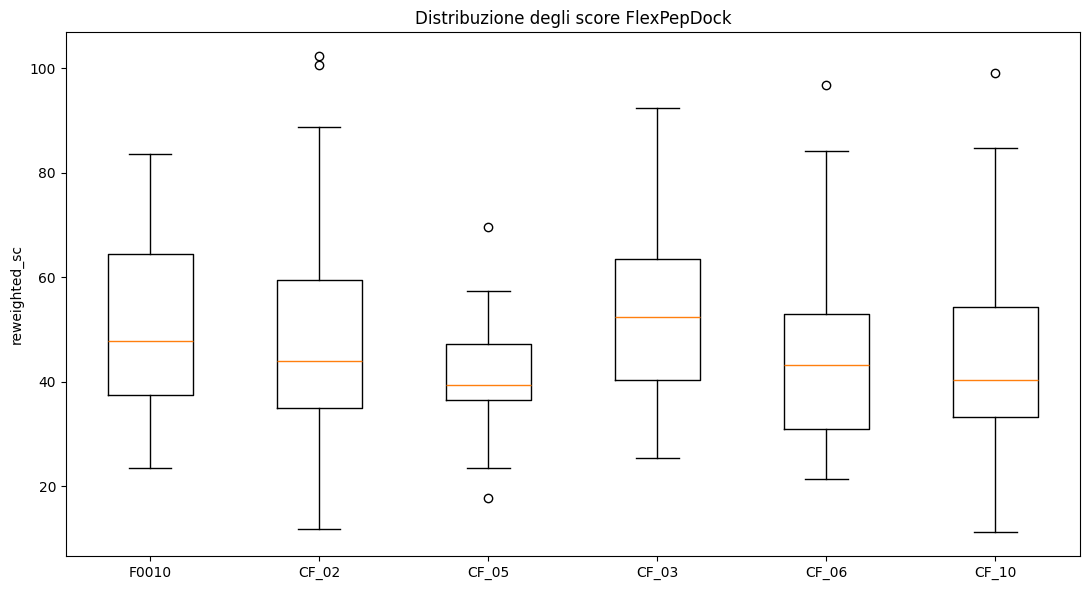

In [34]:
if not all_scores.empty:
    labels = [
        candidate_id
        for candidate_id in panel[
            "candidate_id"
        ]
        if candidate_id in set(
            all_scores["candidate_id"]
        )
    ]

    data = [
        all_scores.loc[
            all_scores["candidate_id"]
            == candidate_id,
            PRIMARY_SCORE,
        ].values
        for candidate_id in labels
    ]

    plt.figure(figsize=(11, 6))
    plt.boxplot(
        data,
        labels=labels,
        showfliers=True,
    )
    plt.ylabel(PRIMARY_SCORE)
    plt.title(
        "Distribuzione degli score FlexPepDock"
    )
    plt.tight_layout()
    plt.savefig(
        REPORTS_DIR
        / "flexpepdock_score_distributions.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

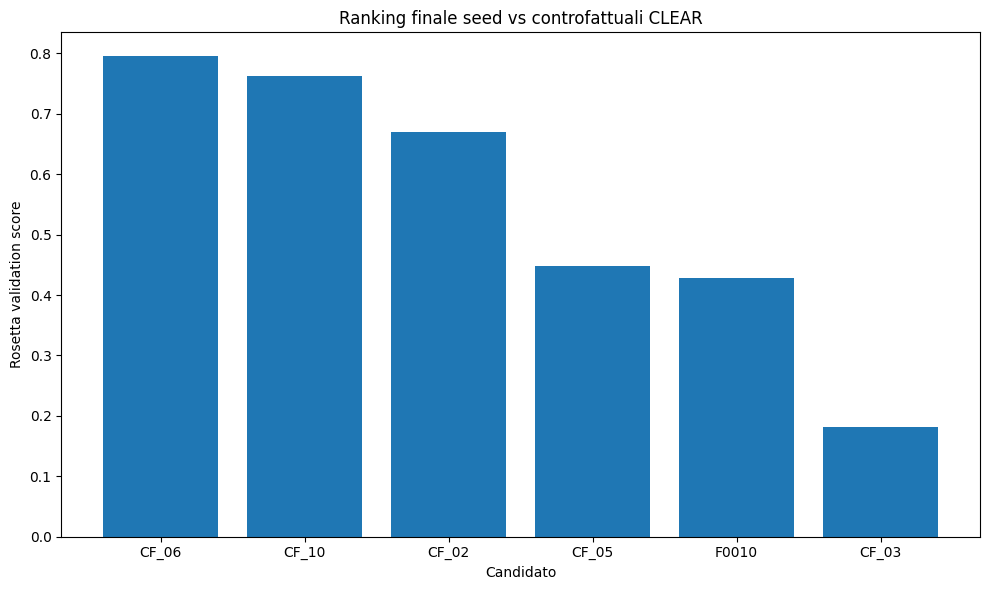

In [35]:
if not final_ranking.empty:
    plt.figure(figsize=(10, 6))
    plt.bar(
        final_ranking["candidate_id"],
        final_ranking[
            "rosetta_validation_score"
        ],
    )
    plt.xlabel("Candidato")
    plt.ylabel("Rosetta validation score")
    plt.title(
        "Ranking finale seed vs controfattuali CLEAR"
    )
    plt.tight_layout()
    plt.savefig(
        REPORTS_DIR
        / "rosetta_final_ranking.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 23. Esportazione

In [36]:
ALL_SCORES_CSV = (
    RESULT_DIR
    / "all_flexpepdock_scores.csv"
)
POSE_RESULTS_CSV = (
    RESULT_DIR
    / "all_pose_structural_metrics.csv"
)
ENERGY_SUMMARY_CSV = (
    RESULT_DIR
    / "candidate_energy_summary.csv"
)
TOP5_SUMMARY_CSV = (
    RESULT_DIR
    / "candidate_top5_structural_summary.csv"
)
FINAL_RANKING_CSV = (
    RESULT_DIR
    / "clear_counterfactual_flexpepdock_final_ranking.csv"
)
BEST_POSE_MANIFEST_CSV = (
    BEST_POSES_DIR
    / "best_pose_manifest.csv"
)
RUN_METADATA_JSON = (
    RESULT_DIR / "05d_run_metadata.json"
)

all_scores.to_csv(
    ALL_SCORES_CSV,
    index=False,
)
pose_results.to_csv(
    POSE_RESULTS_CSV,
    index=False,
)
energy_summary.to_csv(
    ENERGY_SUMMARY_CSV,
    index=False,
)
top5_summary.to_csv(
    TOP5_SUMMARY_CSV,
    index=False,
)
final_ranking.to_csv(
    FINAL_RANKING_CSV,
    index=False,
)
best_pose_manifest.to_csv(
    BEST_POSE_MANIFEST_CSV,
    index=False,
)

metadata = {
    "seed_sequence": SEED_SEQUENCE,
    "n_candidates_including_seed": len(
        panel
    ),
    "nstruct": ROSETTA_NSTRUCT,
    "primary_score": PRIMARY_SCORE,
    "rosetta_binary": ROSETTA_BINARY,
    "rosetta_database": ROSETTA_DATABASE,
    "n_complete_candidates": int(
        final_status["complete"].sum()
    ),
    "ranking_weights": {
        "best_primary_score": 0.25,
        "top5_mean_primary_score": 0.25,
        "best_I_sc": 0.20,
        "contact_recall": 0.15,
        "hotspot_preservation": 0.05,
        "low_rmsd": 0.10,
        "clash_penalty": 0.50,
    },
    "warning": (
        "Computational ranking requires experimental validation."
    ),
}

RUN_METADATA_JSON.write_text(
    json.dumps(
        metadata,
        indent=2,
    ),
    encoding="utf-8",
)

for path in [
    ALL_SCORES_CSV,
    POSE_RESULTS_CSV,
    ENERGY_SUMMARY_CSV,
    TOP5_SUMMARY_CSV,
    FINAL_RANKING_CSV,
    BEST_POSE_MANIFEST_CSV,
    RUN_METADATA_JSON,
]:
    print("Salvato:", path.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d/all_flexpepdock_scores.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d/all_pose_structural_metrics.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d/candidate_energy_summary.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d/candidate_top5_structural_summary.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d/clear_counterfactual_flexpepdock_final_ranking.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d/best_poses/best_pose_manifest.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d/05d_run_metadata.json


## 24. Report automatico

In [37]:
best_row = (
    final_ranking.iloc[0]
    if not final_ranking.empty
    else None
)

seed_final = final_ranking[
    final_ranking["candidate_id"]
    == "F0010"
]

report = f'''# 05d — CLEAR counterfactual FlexPepDock refinement

## Pannello
- Candidati inclusi: {len(panel)}
- Seed incluso: F0010
- nstruct per candidato: {ROSETTA_NSTRUCT}
- Pose attese: {len(panel) * ROSETTA_NSTRUCT}
- Pose analizzate: {len(pose_results)}
- Score primario: `{PRIMARY_SCORE}`

## Miglior candidato finale
- ID: {best_row["candidate_id"] if best_row is not None else "N/A"}
- Sequenza: `{best_row["sequence"] if best_row is not None else "N/A"}`
- Mutazioni: {best_row["mutation_labels"] if best_row is not None else "N/A"}
- Best score: {best_row["best_primary_score"] if best_row is not None else float("nan"):.6f}
- Top-5 mean: {best_row["top5_mean_primary_score"] if best_row is not None else float("nan"):.6f}
- Best I_sc: {best_row["best_I_sc"] if best_row is not None else float("nan"):.6f}
- Top-5 mean RMSD: {best_row["top5_mean_rmsd_A"] if best_row is not None else float("nan"):.6f}
- Top-5 contact recall: {best_row["top5_mean_native_contact_recall"] if best_row is not None else float("nan"):.6f}
- Rosetta validation score: {best_row["rosetta_validation_score"] if best_row is not None else float("nan"):.6f}

## Confronto col seed
Il ranking contiene F0010 come controllo diretto. Le colonne `delta_best_primary_vs_seed` e `delta_top5_mean_vs_seed` indicano valori negativi quando il candidato è energeticamente migliore del seed secondo Rosetta.

## Output principale
`{FINAL_RANKING_CSV}`

## Interpretazione
Un controfattuale è supportato quando mantiene contatti e hotspot e mostra score Rosetta migliori o comparabili al seed in più pose, non soltanto nella migliore posa individuale.
'''

REPORT_PATH = (
    REPORTS_DIR / "05d_flexpepdock_report.md"
)
REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("Report:", REPORT_PATH.resolve())

# 05d — CLEAR counterfactual FlexPepDock refinement

## Pannello
- Candidati inclusi: 6
- Seed incluso: F0010
- nstruct per candidato: 20
- Pose attese: 120
- Pose analizzate: 120
- Score primario: `reweighted_sc`

## Miglior candidato finale
- ID: CF_06
- Sequenza: `IGERCQYRELR`
- Mutazioni: D9E;K11R
- Best score: 21.476000
- Top-5 mean: 24.687400
- Best I_sc: -58.436000
- Top-5 mean RMSD: 0.436995
- Top-5 contact recall: 0.913514
- Rosetta validation score: 0.795041

## Confronto col seed
Il ranking contiene F0010 come controllo diretto. Le colonne `delta_best_primary_vs_seed` e `delta_top5_mean_vs_seed` indicano valori negativi quando il candidato è energeticamente migliore del seed secondo Rosetta.

## Output principale
`outputs/clear_counterfactual_flexpepdock_05d/clear_counterfactual_flexpepdock_final_ranking.csv`

## Interpretazione
Un controfattuale è supportato quando mantiene contatti e hotspot e mostra score Rosetta migliori o comparabili al seed in più pose, non soltanto ne

## 25. Interpretazione finale

### Evidenza forte a favore di un controfattuale

Un candidato è particolarmente convincente quando:

- `delta_best_primary_vs_seed < 0`;
- `delta_top5_mean_vs_seed < 0`;
- `best_I_sc` è migliore del seed;
- contatti nativi e hotspot sono mantenuti;
- non compaiono clash;
- il risultato è stabile sulle migliori 5 pose.

### Passaggio successivo

Dopo il 05d, la pipeline può:

1. selezionare il miglior controfattuale minimo;
2. selezionare il miglior doppio mutante;
3. confrontarli con F0010;
4. eventualmente eseguire:
   - refinement più profondo;
   - dinamica molecolare;
   - analisi di stabilità e persistenza dei contatti;
   - sintesi sperimentale.
